# 05B - Store Sales Forecasting - Full Data Time Series Cross Validation

## Objective

Evaluate the advanced forecasting pipeline using walk-forward cross-validation on the full available training dataset.

Main goals:

- keep the same validated advanced feature pipeline
- extend validation from the recent 365-day subset to the full training history
- estimate model performance on a broader temporal range
- inspect temporal stability across folds
- log the validation process in MLflow

## Why this notebook

Previous experiments used the last 365 days to keep iteration fast and consistent.

This notebook upgrades the validation stage by applying the same advanced pipeline to the full training history, using walk-forward temporal validation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

sys.path.append(str(Path().resolve().parent))

from src.features import add_baseline_features, add_advanced_features, encode_family
from src.metrics import evaluate_regression

## Setup

Use the same advanced feature pipeline and the same LightGBM configuration adopted in NB4 and NB5.

Key difference:
- `USE_FULL_DATA = True`
- validation is performed with walk-forward cross-validation on the full dataset

In [2]:
SEED = 42
DATA_DIR = Path("../data")

USE_FULL_DATA = True
LAST_N_DAYS = None  

MLFLOW_EXPERIMENT_NAME = "store_sales_forecasting"
MLFLOW_TRACKING_URI = "file:../mlruns"

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())
print("Tracking URI:", MLFLOW_TRACKING_URI)
print("Use full data:", USE_FULL_DATA)

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data
Tracking URI: file:../mlruns
Use full data: True


## MLflow setup

Track the full-data cross-validation experiment as a dedicated MLflow run.

In [3]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Active experiment:", MLFLOW_EXPERIMENT_NAME)

Active experiment: store_sales_forecasting


## Load data

Load the Store Sales dataset and inspect the available date range.

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Sorting

Sort each `(store_nbr, family)` series by date to preserve temporal consistency before building lag and rolling features.

In [5]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


## Dataset scope

This notebook uses the full training dataset.

The subset logic from earlier notebooks is intentionally disabled here.

In [6]:
if not USE_FULL_DATA:
    cutoff = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff].copy()

print("Train shape after scope selection:", train.shape)
print("Date range after scope selection:", train["date"].min(), "->", train["date"].max())

Train shape after scope selection: (3000888, 6)
Date range after scope selection: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00


## Calendar features

Create the same calendar features used in the previous notebooks.

In [7]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]].head())

,date,year,month,day,dayofweek,weekofyear,is_weekend
0,2013-01-01,2013,1,1,1,1,0
1782,2013-01-02,2013,1,2,2,1,0
3564,2013-01-03,2013,1,3,3,1,0
5346,2013-01-04,2013,1,4,4,1,0
7128,2013-01-05,2013,1,5,5,1,1


## Rebuild advanced feature pipeline

Reuse the same advanced feature engineering pipeline introduced in NB3 and validated in NB4/NB5.

No new feature engineering is introduced here.

In [8]:
advanced_train = add_baseline_features(train)
advanced_train = add_advanced_features(advanced_train)
advanced_train = advanced_train.dropna().copy()

advanced_train, advanced_test, family_mapping = encode_family(advanced_train, test)

advanced_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "trend_1_7",
    "promo_last_7",
]

print("Advanced dataset shape:", advanced_train.shape)
print("Number of features:", len(advanced_features))
print("Advanced date range:", advanced_train["date"].min(), "->", advanced_train["date"].max())

Advanced dataset shape: (2975940, 19)
Number of features: 16
Advanced date range: 2013-01-15 00:00:00 -> 2017-08-15 00:00:00


## Walk-forward validation design

Use expanding-window walk-forward validation anchored near the end of the dataset.

Why:
- the goal is to validate the model on recent periods, closer to the final forecasting horizon
- each fold trains on all past data available up to that point
- each validation window covers the next 28 days
- this produces a more realistic estimate than validating very early periods from the start of the dataset

In [9]:
unique_dates = np.array(sorted(advanced_train["date"].unique()))

n_folds = 4
val_size = 28  # 4 weeks

folds = []

# anchor folds near the end of the dataset
last_val_end_idx = len(unique_dates) - 1

for i in range(n_folds):
    # build folds from older recent period -> most recent period
    offset = (n_folds - 1 - i) * val_size

    val_end_idx = last_val_end_idx - offset
    val_start_idx = val_end_idx - val_size + 1
    train_end_idx = val_start_idx - 1

    # safety check: require enough training history
    if train_end_idx < 365:
        break

    folds.append({
        "fold": i + 1,
        "train_end": unique_dates[train_end_idx],
        "val_start": unique_dates[val_start_idx],
        "val_end": unique_dates[val_end_idx],
    })

folds_df = pd.DataFrame(folds)
display(folds_df)

,fold,train_end,val_start,val_end
0,1,2017-04-25,2017-04-26,2017-05-23
1,2,2017-05-23,2017-05-24,2017-06-20
2,3,2017-06-20,2017-06-21,2017-07-18
3,4,2017-07-18,2017-07-19,2017-08-15


## Fold inspection

Inspect fold boundaries before running validation.

In [10]:
for fold_info in folds:
    print(
        f"Fold {fold_info['fold']} | "
        f"train <= {pd.Timestamp(fold_info['train_end']).date()} | "
        f"val: {pd.Timestamp(fold_info['val_start']).date()} -> {pd.Timestamp(fold_info['val_end']).date()}"
    )

Fold 1 | train <= 2017-04-25 | val: 2017-04-26 -> 2017-05-23
Fold 2 | train <= 2017-05-23 | val: 2017-05-24 -> 2017-06-20
Fold 3 | train <= 2017-06-20 | val: 2017-06-21 -> 2017-07-18
Fold 4 | train <= 2017-07-18 | val: 2017-07-19 -> 2017-08-15


## Walk-forward cross-validation

Train and evaluate the advanced LightGBM model across all folds.

Primary metric:
- RMSLE

Supporting metrics:
- MAE
- RMSE
- R²

The goal is not only to measure average performance, but also to inspect temporal stability across folds.

In [11]:
cv_results = []

with mlflow.start_run(run_name="validation_lgm_advanced_v1_full_data_cv"):
    mlflow.set_tags({
        "project": "store_sales_forecasting",
        "notebook": "nb5_full_data",
        "model_family": "lightgbm",
        "experiment_type": "time_series_cross_validation",
        "validation_strategy": "walk_forward",
        "dataset_scope": "full_data",
        "primary_metric": "rmsle_mean",
    })

    mlflow.log_params({
    "model_type": "LGBMRegressor",
    "feature_set": "advanced_v1",
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": SEED,
    "use_full_data": USE_FULL_DATA,
    "n_features": len(advanced_features),
    "n_folds": len(folds),
    "val_size_days": val_size,
    "fold_strategy": "anchored_recent_walk_forward",
    })

    for fold_info in folds:
        fold = fold_info["fold"]
        train_end = fold_info["train_end"]
        val_start = fold_info["val_start"]
        val_end = fold_info["val_end"]

        train_fold = advanced_train[advanced_train["date"] <= train_end].copy()
        val_fold = advanced_train[
            (advanced_train["date"] >= val_start) &
            (advanced_train["date"] <= val_end)
        ].copy()

        X_train = train_fold[advanced_features]
        y_train = train_fold["sales"]
        X_val = val_fold[advanced_features]
        y_val = val_fold["sales"]

        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=SEED,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)

        metrics = evaluate_regression(y_val, y_pred)

        row = {
            "fold": fold,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end,
            "n_train": len(train_fold),
            "n_val": len(val_fold),
            **metrics,
        }
        cv_results.append(row)

        mlflow.log_metric(f"rmsle_fold_{fold}", metrics["rmsle"])
        mlflow.log_metric(f"mae_fold_{fold}", metrics["mae"])
        mlflow.log_metric(f"rmse_fold_{fold}", metrics["rmse"])
        mlflow.log_metric(f"r2_fold_{fold}", metrics["r2"])

        print(
            f"Fold {fold} | "
            f"RMSLE={metrics['rmsle']:.6f} | "
            f"MAE={metrics['mae']:.3f} | "
            f"RMSE={metrics['rmse']:.3f} | "
            f"R2={metrics['r2']:.6f}"
        )

    cv_results_df = pd.DataFrame(cv_results)

    rmsle_mean = cv_results_df["rmsle"].mean()
    rmsle_std = cv_results_df["rmsle"].std()
    mae_mean = cv_results_df["mae"].mean()
    rmse_mean = cv_results_df["rmse"].mean()
    r2_mean = cv_results_df["r2"].mean()

    mlflow.log_metric("rmsle_mean", float(rmsle_mean))
    mlflow.log_metric("rmsle_std", float(rmsle_std))
    mlflow.log_metric("mae_mean", float(mae_mean))
    mlflow.log_metric("rmse_mean", float(rmse_mean))
    mlflow.log_metric("r2_mean", float(r2_mean))

    print("\nCross-validation completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2189
[LightGBM] [Info] Number of data points in the train set: 2776356, number of used features: 16
[LightGBM] [Info] Start training from score 350.248207
Fold 1 | RMSLE=0.600119 | MAE=78.626 | RMSE=298.492 | R2=0.952325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.116601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2191
[LightGBM] [Info] Number of data points in the train set: 2826252, number of used features: 16
[LightGBM] [Info] Start training from score 352.734481
Fold 2 | RMSLE=0.614805 | MAE=71.947 | RMSE=267.177 | R2=0.962979
[LightGBM] [Info] Auto-choosing row-wise multi-t

## Cross-validation results

Inspect fold-by-fold metrics and aggregated results.

In [12]:
display(cv_results_df)

summary = pd.DataFrame([{
    "rmsle_mean": cv_results_df["rmsle"].mean(),
    "rmsle_std": cv_results_df["rmsle"].std(),
    "mae_mean": cv_results_df["mae"].mean(),
    "rmse_mean": cv_results_df["rmse"].mean(),
    "r2_mean": cv_results_df["r2"].mean(),
}])

display(summary)

,fold,train_end,val_start,val_end,n_train,n_val,rmsle,mae,rmse,r2
0,1,2017-04-25,2017-04-26,2017-05-23,2776356,49896,0.600119,78.625545,298.492309,0.952325
1,2,2017-05-23,2017-05-24,2017-06-20,2826252,49896,0.614805,71.947313,267.177052,0.962979
2,3,2017-06-20,2017-06-21,2017-07-18,2876148,49896,0.579065,58.081478,211.644822,0.974482
3,4,2017-07-18,2017-07-19,2017-08-15,2926044,49896,0.605530,65.136453,217.512603,0.970692


,rmsle_mean,rmsle_std,mae_mean,rmse_mean,r2_mean
0,0.59988,0.015144,68.447697,248.706697,0.965119


## Comparison with the subset-based validation

Compare the full-data validation results with the earlier walk-forward validation performed on the 365-day subset.

In [13]:
nb5_subset_rmsle_mean = 0.687081
nb5_subset_rmsle_std = 0.035215

comparison_df = pd.DataFrame([
    {
        "validation": "NB5 subset (365d)",
        "rmsle_mean": nb5_subset_rmsle_mean,
        "rmsle_std": nb5_subset_rmsle_std,
    },
    {
        "validation": "NB5 full data",
        "rmsle_mean": cv_results_df["rmsle"].mean(),
        "rmsle_std": cv_results_df["rmsle"].std(),
    },
])

display(comparison_df)

print("NB5 subset RMSLE mean:", round(nb5_subset_rmsle_mean, 6))
print("NB5 subset RMSLE std :", round(nb5_subset_rmsle_std, 6))
print("NB5 full RMSLE mean  :", round(cv_results_df["rmsle"].mean(), 6))
print("NB5 full RMSLE std   :", round(cv_results_df["rmsle"].std(), 6))

,validation,rmsle_mean,rmsle_std
0,NB5 subset (365d),0.687081,0.035215
1,NB5 full data,0.599880,0.015144


NB5 subset RMSLE mean: 0.687081
NB5 subset RMSLE std : 0.035215
NB5 full RMSLE mean  : 0.59988
NB5 full RMSLE std   : 0.015144


## Temporal stability plot

Visualize RMSLE variation across folds.

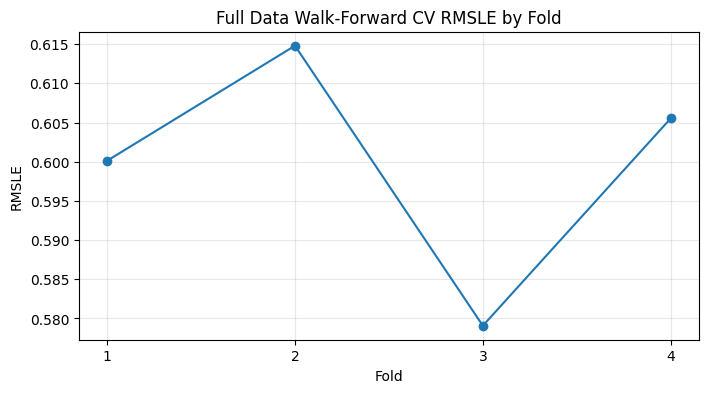

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(cv_results_df["fold"], cv_results_df["rmsle"], marker="o")
plt.title("Full Data Walk-Forward CV RMSLE by Fold")
plt.xlabel("Fold")
plt.ylabel("RMSLE")
plt.xticks(cv_results_df["fold"])
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

Use the fold results to answer two questions:

1. Is the advanced model still robust when validated on the full dataset?
2. Does performance remain stable across time, or does it vary significantly between periods?

Key interpretation points:
- lower RMSLE mean indicates better average forecasting quality
- lower RMSLE std indicates greater temporal stability
- differences between folds may reveal more difficult business periods

## Conclusion

This notebook extends the validation stage by applying walk-forward cross-validation to the full training history.

Compared to the earlier subset-based validation (last 365 days), this approach provides a more realistic and robust estimate of model performance by leveraging the entire available historical data.

Key results:
- RMSLE mean: ~0.600
- RMSLE std: ~0.015

These results indicate:
- improved average performance compared to the subset-based validation (RMSLE ~0.687)
- significantly lower variability across folds, suggesting higher temporal stability

The model shows consistent performance across recent validation periods (2017), which are closest to the final forecasting horizon.

Important note:
- the improvement in metrics is mainly due to a more robust validation setup and larger training history, rather than changes in the model itself

Conclusion:
- the advanced LightGBM pipeline is considered stable and suitable for final retraining
- this notebook represents the primary validation reference for the project

Next step:
- retrain the selected model on the full dataset (NB6)
- register the final candidate in the Model Registry